#### What is a Heatmap (heatmap)?
A heatmap is a graphical representation of data where the individual values contained in a matrix are represented as colors. It's a 2D grid where each cell's color corresponds to its value.

Think of it as "coloring by numbers" for a table. Darker shades or "hotter" colors (like red and orange) typically represent higher values, while lighter shades or "colder" colors (like blue and green) represent lower values. This allows you to instantly spot patterns, clusters, and extremities in your data that would be very hard to see in a raw table of numbers.

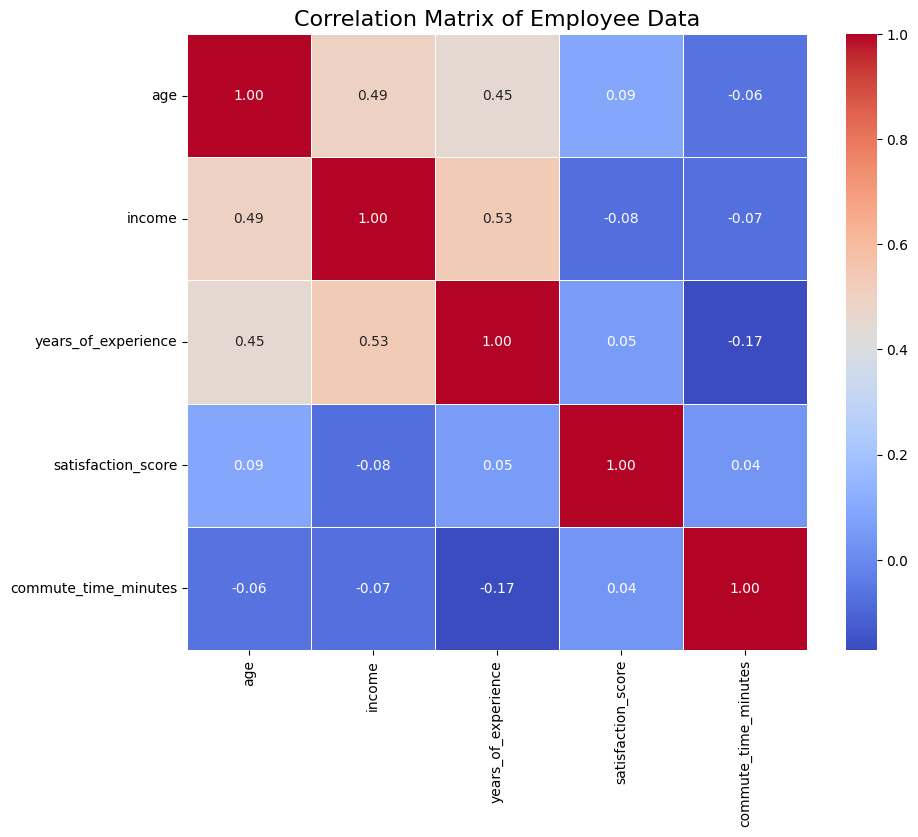

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# 1. Sample Data
# Create a DataFrame with some correlated and uncorrelated numerical features
np.random.seed(42)
data = {
    'age': np.random.randint(20, 60, 100),
    'income': np.random.randint(40000, 150000, 100),
    'years_of_experience': np.random.randint(0, 40, 100),
    'satisfaction_score': np.random.randint(1, 10, 100),
    'commute_time_minutes': np.random.randint(5, 90, 100)
}
df = pd.DataFrame(data)

# Intentionally create some correlations
df['income'] = df['income'] + df['age'] * 1500 + df['years_of_experience'] * 1000
df['years_of_experience'] = df['years_of_experience'] + df['age'] * 0.5

# 2. Calculate the Correlation Matrix
# This is the 2D matrix that we will visualize.
correlation_matrix = df.corr()

# 3. Sample Code for the Plot
plt.figure(figsize=(10, 8))

# Create the heatmap using seaborn
# data: The 2D matrix (our correlation matrix)
# annot: If True, write the data value in each cell. This is crucial for readability.
# cmap: The color map to use. 'coolwarm' is great for correlation as it's centered on 0.
# fmt: String formatting code to use when adding annotations. '.2f' means 2 decimal places.
# linewidths: Width of the lines that will divide each cell.
sns.heatmap(
    correlation_matrix,
    annot=True, # Display the correlation values on the heatmap
    cmap='coolwarm', # Use a color map that shows positive (hot) and negative (cold) correlations
    fmt='.2f', # Format the annotations to two decimal places
    linewidths=.5 # Add lines between cells for clarity
)

# Add title
plt.title('Correlation Matrix of Employee Data', fontsize=16)
plt.show()

#### What Type of Information It Provides
A heatmap is excellent at revealing patterns across a 2D grid of data.

Spotting High and Low Values: This is its most basic function. Your eyes are immediately drawn to the "hottest" and "coldest" cells, allowing you to find the maximum and minimum values in the matrix instantly.

Identifying Patterns and Clusters: You can easily see blocks of similar colors, which indicate clusters or groups of related items. For example, you might see that a group of features are all highly correlated with each other.

Correlation Analysis (Primary Use Case): When used on a correlation matrix, a heatmap shows:

Strong Positive Correlation: Dark "hot" colors (e.g., dark red) indicate a strong positive linear relationship (as one variable goes up, the other goes up). In our example, age, income, and years_of_experience form a hot block.
Strong Negative Correlation: Dark "cold" colors (e.g., dark blue) indicate a strong negative linear relationship (as one variable goes up, the other goes down).
No Correlation: Colors near the center of the color map (e.g., white or light gray) indicate a value close to zero, meaning no linear relationship.
The diagonal is always a perfect positive correlation (1.0) because a variable is perfectly correlated with itself.


Scenarios for Using a Heatmap
1. During Exploratory Data Analysis (EDA)
Visualizing Correlation Matrices: This is a standard and essential step in almost any EDA workflow. It helps you understand the relationships between your numerical features and is the primary way to detect multicollinearity (when two or more features are highly correlated), which can be a problem for some machine learning models.
Visualizing Missing Data Patterns: You can create a heatmap of missing values (sns.heatmap(df.isnull())) to see if there are any patterns. For example, you might see that if value_A is missing, value_B is also often missing.
Visualizing Contingency Tables: For two categorical variables, you can create a contingency table (crosstab) of their frequencies and then use a heatmap to visualize which combinations are most common.
2. During Model Diagnostics and Evaluation (Post-Model Generation)
Visualizing a Confusion Matrix: This is a perfect application. A confusion matrix is a 2D grid showing how a classification model's predictions line up with the actual labels. A heatmap makes it instantly clear where the model is performing well (high values on the diagonal) and where it is getting "confused" (high values off the diagonal).
3. Other Applications
Time-Series Data: To show how a metric changes over two time-based categories. For example, plotting number_of_sales with hour_of_day on the y-axis and day_of_week on the x-axis to find the "hottest" sales periods.
Genomics, Finance, and more: Any field that works with matrix data can benefit from heatmaps to find patterns.